<a href="https://colab.research.google.com/github/grov3000/project/blob/main/hw06_%D0%90dodin_Artyom_texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [ ]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [ ]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
7561,12977,57929,"Edina, MN and Washington, DC",20-03-2020,BREAKING: McConnellÃÂs proposal for Coronavi...,Positive
17420,24991,69943,NaN,25-03-2020,Everyday tasks like going to the grocery store...,Extremely Negative
5986,11065,56017,United Kingdom,19-03-2020,"So done with @monzo , IÃÂm out buying food b...",Negative
5569,10564,55516,Lost,19-03-2020,TheyÃÂre also lying. Spoke to my local corne...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [ ]:
df['Sentiment'] = (df['Sentiment'].isin(['Positive', 'Extremely Positive'])).astype(int)

Сбалансированы ли классы?

In [ ]:
col_1 = df['Sentiment'].sum()
col_0 = len(df['Sentiment']) - col_1
print("Количество 1:", col_1)
print("Количество 0:", col_0)


Количество 1: 18046
Количество 0: 15398


**Ответ:** Да, классы сбалансированы, так как нет большой разницы между класса.

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [ ]:
print(df.isnull().sum())

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64


In [ ]:
df = df.fillna('Unknown')
print(df.isnull().sum())

UserName         0
ScreenName       0
Location         0
TweetAt          0
OriginalTweet    0
Sentiment        0
dtype: int64


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split( df, test_size=0.7, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [ ]:
from collections import Counter
text = df['OriginalTweet'].tolist()

tok = []
for i in text:
  tokens = str(i).lower().split()
  tok.extend(tokens)

voc = Counter(tok)


Какой размер словаря получился?

In [ ]:
print(len(voc))

103200


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [ ]:
for a, count  in voc.most_common(10):
  print(f'"{a}" : {count}')

"the" : 38250
"to" : 33447
"and" : 20935
"of" : 18578
"a" : 16667
"in" : 16024
"for" : 12193
"#coronavirus" : 11759
"is" : 10596
"are" : 9958


**Ответ:** Слово coronavirus объяснимо в топе, так как твиты на эту тему. Все остальные слова как предлоги и союзы, они часто используется в связи между словами. Являются стоп-словами.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [ ]:
import nltk
from nltk.corpus import stopwords



nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
new_token = [ token for token in tok if token not in stop_words]

new_voc = Counter(new_token)
for token, count  in new_voc.most_common(10):
  print(f'"{token}" : {count}')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


"#coronavirus" : 11759
"prices" : 5625
"food" : 5409
"grocery" : 4882
"supermarket" : 4662
"covid-19" : 4504
"people" : 4488
"store" : 4486
"#covid19" : 3561
"consumer" : 3233


**Ответ:**  #coronavirus, #covid19, people, covid-19,  prices - можно сказать ключивые слова темы короновируса. Остальные слова вытекающие из темы короновируса, введенные огроничения повлияли на цены, работу магазинов и тд. Отсюда и появление этих слов в постах.





Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [ ]:
for token, count  in new_voc.most_common()[:-21:-1]:
  print(f'"{token}" : {count}')

"whethe" : 1
"$700.00" : 1
"rift" : 1
"new/used" : 1
"@tartiicat" : 1
"martinsville," : 1
"@kameronwilds" : 1
"rejecting" : 1
"delays." : 1
"@mrsilverscott" : 1
"https://t.co/v8xdxhqeyn" : 1
"home??" : 1
"https://t.co/s8coy5vvgn" : 1
"gms." : 1
"rs.46,215" : 1
"$1,722.20" : 1
"dec." : 1
"$1,715.25/ounce" : 1
"#safe-haven" : 1
"bullion's" : 1


**Ответ:** вижу некоторые группы токенов

1.   Слова написанные с ошибкой.
2.   электорнные почты или ссылки.
3.   Цены.
4.   неправильная пунктуация, точка или запитая с словом.

Такие токены редки, так как электронная почта или ссылки в еденичном экземпляре, слова с ошибкой. С пунтктуацией  и ошибками можно поработать, чтобы эти слова тоже учитывались. цены или ссылки можно заменять одним словом








Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [ ]:
from nltk.tokenize import TweetTokenizer

tw = TweetTokenizer()

tok_tw= []
for i in text:
    tokens_tw = tw.tokenize(str(i))
    tok_tw.extend(tokens_tw)


voc_tw = Counter(tok_tw)

for token_tw, count_tw  in voc_tw.most_common(10):
  print(f'"{token_tw}" : {count_tw}')

"the" : 34781
"." : 34284
"to" : 32812
"," : 25142
"and" : 20439
"of" : 18429
"a" : 15679
"in" : 15143
"?" : 13730
"for" : 11722


**Ответ:** Появились знаки пунктуации, теперь они являются отдельными токенами, в чем и особенность TweetTokenizer.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [ ]:
from string import punctuation

nltk.download('stopwords')
stop_word = set(stopwords.words('english'))

stop_word.update(punctuation)

token_tw = [token for token in tok_tw if token not in stop_word]
voc_tw = Counter(token_tw)

for token_t, count_tw  in voc_tw.most_common(10):
  print(f'"{token_t}" : {count_tw}')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


"Â" : 10498
"" : 10361
"#coronavirus" : 10211
"19" : 10142
"I" : 7484
"" : 6190
"prices" : 6166
"COVID" : 5945
"food" : 5423
"store" : 5234


**Ответ:** Да теперь есть непонятные символы, которые учитывает токенайзер TweetTokenizer. Например:  . Появились символы A I в верхних регистрах.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [ ]:

filter_token = [token for token in token_tw if not (len(token) == 1 and ord(token) >= 128)]


filter_voc = Counter(filter_token)
print("Самые популярные :")
for token_t, count_tw  in filter_voc.most_common(10):
  print(f'"{token_t}" : {count_tw}')
print("Самые непопулярные :")
for token_t, count_tw  in filter_voc.most_common()[:-21:-1]:
  print(f'"{token_t}" : {count_tw}')



Самые популярные :
"#coronavirus" : 10211
"19" : 10142
"I" : 7484
"prices" : 6166
"COVID" : 5945
"food" : 5423
"store" : 5234
"supermarket" : 4803
"grocery" : 4350
"people" : 4300
Самые непопулярные :
"whethe" : 1
"700.00" : 1
"Rift" : 1
"@TartiiCat" : 1
"martinsville" : 1
"@KameronWilds" : 1
"TAT" : 1
"rejecting" : 1
"@MrSilverScott" : 1
"roulette" : 1
"https://t.co/v8XDXhqeYN" : 1
"https://t.co/S8coY5VVgN" : 1
"gms" : 1
"46,215" : 1
"1,722" : 1
"1,715" : 1
"#safe-haven" : 1
"bullion's" : 1
"@MajangChien" : 1
"https://t.co/qUQ8Y0uM6n" : 1


**Ответ:**
Исчезли комбинации слов и символов, которые вместе бы имели быльше смысла, чем отдельно, например covid-19 в новом словаре разбился на covid и 19, а - вообще исчезло. Так же возможно потеряются симловолы, например :) , которое тоже несут смысл. Но токены стали чище и легче для понимания, ушли непонятные символы.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [ ]:
h_token = [token for token in filter_token if token.startswith('#')]


h_voc = Counter(h_token)
print("Самые популярные :")
for token_t, count_t  in h_voc.most_common(10):
  print(f'"{token_t}" : {count_t}')

Самые популярные :
"#coronavirus" : 10211
"#COVID19" : 2621
"#Covid_19" : 2126
"#Coronavirus" : 1806
"#COVID2019" : 1341
"#toiletpaper" : 944
"#covid19" : 829
"#COVID" : 775
"#CoronaCrisis" : 599
"#CoronaVirus" : 525


**Ответ:** Видно, что почти все хештеги связаны с темой короновируса. Это объяснимо темой подборки хештегов. Есть тема таулетной бумаги - это можно объяснить спросом на товары личной гигиены в период пандемии.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [ ]:
from collections import Counter
links = [token for token in tok if 't.co' in token]
link_counts = Counter(links)
for link, count in link_counts.most_common(10):
    print(f"{link}: {count}")

https://t.co/oxa7swtond: 6
https://t.co/g63rp042ho: 5
https://t.co/r7sagojsjg: 4
https://t.co/wrlhyzizaa: 4
https://t.co/ymsemlvttd: 4
https://t.co/3kfuiojxep.: 4
https://t.co/oi39zsanq8: 4
https://t.co/6yvykiab2c: 4
https://t.co/xpcm2xkj4o: 4
https://t.co/gu6b4xpqp4: 4


**Ответ:** нет, ссылки уступают по популянрности хештегам, десятки штук против тысяч, как видно выше. Информация о ссылке полезна, если анализировать статистику источника, как часто использовался, для анализа тональности ссылки выступают, как шум.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [ ]:

stop_words = set(stopwords.words('english'))
stop_words.update(punctuation)

def custom_tokenizer(text):
  text = text.lower()
  t = tw.tokenize(str(text))
  t = [t for t in t if t not in stop_words]
  t = [t for t in t if not (len(t) == 1 and ord(t) >= 128)]
  t = [t for t in t if 't.co' not in t]

  return t


In [ ]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer (tokenizer=custom_tokenizer)
X = cv.fit_transform(df['OriginalTweet'])

print(len(cv.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


56505


**Ответ:**  Размер нового словаря почти в 2 раза меньше, чем в задание 2. Это объяснимо, тем что новый токенизатор удаляет стоп-слова, приводит к нижниму регистору, всякие непонятные символы убирает, в общем убирает то, что нам сказали в задание выше.

Посмотрим на какой-нибудь конкретный твитт:

In [ ]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

("@AsdaServiceTeam thank you my shopping is being delivered yes with stuff missing but I've got the stuff I need most snacks for kids.. cat food and Wine!! #COVID2019 #coronavirus #supermarket #thankyou ???",
 np.int64(1))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [ ]:
ind = 9023
text = train.iloc[ind]['OriginalTweet']
vec = cv.transform([text])

ind  = vec.indices
val = vec.data

max_idx = ind[val.argmax()]
max_token = list(cv.vocabulary_.keys())[list(cv.vocabulary_.values()).index(max_idx)]
max_count = val.max()

min_idx = ind[val.argmin()]
min_token = list(cv.vocabulary_.keys())[list(cv.vocabulary_.values()).index(min_idx)]
min_count = val.min()
print(f"{max_token}: {max_count}")
print(f"{min_token}: {min_count}")

stuff: 2
#coronavirus: 1


**Ответ:** stuff - здесь не самое главное слово, так как оно не несет окраски текста, более разумно было бы выделить слово missing. #coronavirus - здесь не имеет смысла, так как речь не про него, так что он правильно определен, как не важный токен.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer(tokenizer=custom_tokenizer)
X_tv = tv.fit_transform(train['OriginalTweet'])
vec_tv = tv.transform([text])

ind = vec_tv.indices
val = vec_tv.data

max_idx = ind[val.argmax()]
max_token = list(tv.vocabulary_.keys())[list(tv.vocabulary_.values()).index(max_idx)]
max_tv = val.max()

min_idx = ind[val.argmin()]
min_token = list(tv.vocabulary_.keys())[list(tv.vocabulary_.values()).index(min_idx)]
min_tv = val.min()

print(f"{max_token}: {max_tv:.4f}")
print(f"{min_token}: {min_tv:.4f}")

stuff: 0.4260
#coronavirus: 0.0704


**Ответ:** Определились снова те же токены, это можно объяснить тем что твит не супер негативный и stuff единственное слово, встречающееся 2 раза, отсюда его считают ключевым.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [ ]:
train[train['OriginalTweet'].apply(lambda x: 'your_good_word_here' in x) & (train['Sentiment'] == 1)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment


In [ ]:
positive_tweets = train[(train['Sentiment'] == 1) &
                        (train['OriginalTweet'].str.contains('great|amazing|good'))]
ind = positive_tweets.index[14]
text = positive_tweets.loc[ind, 'OriginalTweet']

In [ ]:
print(text)
vec = cv.transform([text])

ind  = vec.indices
val = vec.data

max_idx = ind[val.argmax()]
max_token = list(cv.vocabulary_.keys())[list(cv.vocabulary_.values()).index(max_idx)]
max_count = val.max()

min_idx = ind[val.argmin()]
min_token = list(cv.vocabulary_.keys())[list(cv.vocabulary_.values()).index(min_idx)]
min_count = val.min()
print(f"{max_token}: {max_count}")
print(f"{min_token}: {min_count}")





? Alexas_Fotos, pixabay. https://t.co/e35C60HGKK
good: 2
#coronacrisis: 1


**Ответ:** good - выделился, как самый важный токен, так как твит написан в положительном контексте и слово встречается там 2 раза. хештег короновирус не так важен для эмоцианальной окраски, так как твит с таким хештегом может быть, как положительным, так и отрицательным.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [ ]:
X = df['OriginalTweet']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

tv = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
X_train_tv = tv.fit_transform(X_train)
X_test_tv = tv.transform(X_test)

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_cv = LogisticRegression(max_iter=1000)
lr_cv.fit(X_train_cv, y_train)
y_pred_cv_train = lr_cv.predict(X_train_cv)
y_pred_cv_test = lr_cv.predict(X_test_cv)

lr_tv = LogisticRegression(max_iter=1000)
lr_tv.fit(X_train_tv, y_train)
y_pred_tv_train = lr_tv.predict(X_train_tv)
y_pred_tv_test = lr_tv.predict(X_test_tv)

print(f"CountVectorizer train: {accuracy_score(y_train, y_pred_cv_train):.4f}")
print(f"CountVectorizer test: {accuracy_score(y_test, y_pred_cv_test):.4f}")
print(f"TfidfVectorizer train: {accuracy_score(y_train, y_pred_tv_train):.4f}")
print(f"TfidfVectorizer test: {accuracy_score(y_test, y_pred_tv_test):.4f}")

CountVectorizer train: 0.9821
CountVectorizer test: 0.8780
TfidfVectorizer train: 0.9246
TfidfVectorizer test: 0.8559


**Ответ:** CountVectorizer - показал себя лучше на тесте и трейне, чем TfidfVectorizer . Это можно объяснить тем, что частота слов в твитери оказалась вважнее, чем их редкость, ведь в этом отличие этих двух моделей. У каждой модели есть переобучение, причем у CountVectorizer оно значительной, так разница больше 0.1.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [ ]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer('english')

def custom_stem_tokenizer(text):
  tokens = tw.tokenize(str(text))
  tokens = [t for t in tokens if t not in stop_words]
  tokens = [t for t in tokens if not (len(t) == 1 and ord(t) >= 128)]
  tokens = [t for t in tokens if 't.co' not in t]
  tokens = [stemmer.stem(t) for t in tokens]
  return tokens

In [ ]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['this',
 'sampl',
 'text',
 '@sample_text',
 'i',
 '#sampletext',
 'ad',
 'word',
 'check',
 'stem']

In [ ]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer)
cv.fit(df['OriginalTweet'])
print(len(cv.vocabulary_))

tv = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
tv.fit(df['OriginalTweet'])
print(len(tv.vocabulary_))



/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


46268
46268


**Ответ** словарь конечно меньше, чем был, примерно на 10000, так как использованы в методе образующие слова

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [ ]:

cv = CountVectorizer(tokenizer=custom_stem_tokenizer)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

tv = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
X_train_tv = tv.fit_transform(X_train)
X_test_tv = tv.transform(X_test)

lr_cv = LogisticRegression(max_iter=1000)
lr_cv.fit(X_train_cv, y_train)
lr_tv = LogisticRegression(max_iter=1000)
lr_tv.fit(X_train_tv, y_train)
print(f"  Train accuracy: {accuracy_score(y_train, lr_cv.predict(X_train_cv))}")
print(f"  Test accuracy:  {accuracy_score(y_test, lr_cv.predict(X_test_cv))}")

print(f"  Train accuracy: {accuracy_score(y_train, lr_tv.predict(X_train_tv))}")
print(f"  Test accuracy:  {accuracy_score(y_test, lr_tv.predict(X_test_tv))}")

  Train accuracy: 0.9705101850121473
  Test accuracy:  0.8760651816415009
  Train accuracy: 0.9156045598953466
  Test accuracy:  0.8651517416654209


**Ответ:** Точности SnowballStemmer моделям не добавил, так как его задача сократить размер словаря, что позволит сыкономить время, но это плохо скажется на смысловой нагрузке текста.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.34
                        ).fit(
                           df['OriginalTweet']
                            )
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


46267


In [ ]:
# -- YOUR CODE HERE --

**Ответ:** значение получилось небольшим, так как даже самое популярное слово встречается в небольшом кол-во текстов в процентном соотношении


Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=0.0004486
                        ).fit(
                           df['OriginalTweet']
                            )
print(len(cv_df.vocabulary_))

3609


In [ ]:
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_cv, y_train)

print(f"Train accuracy: {accuracy_score(y_train, lr.predict(X_train_cv)):}")
print(f"Test accuracy: {accuracy_score(y_test, lr.predict(X_test_cv)):}")


Train accuracy: 0.9705101850121473
Test accuracy: 0.8760651816415009


**Ответ:** точность не потерялась, при уменьшение словаря. 0.0004486 говорит о том, что удаляются слова, встречающиеся где-то в 1 твитере, качество не меняется, так как редкие токены не влияют на обучение модели.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Train accuracy: 0.9999626238086339
Test accuracy: 0.7812827029451338


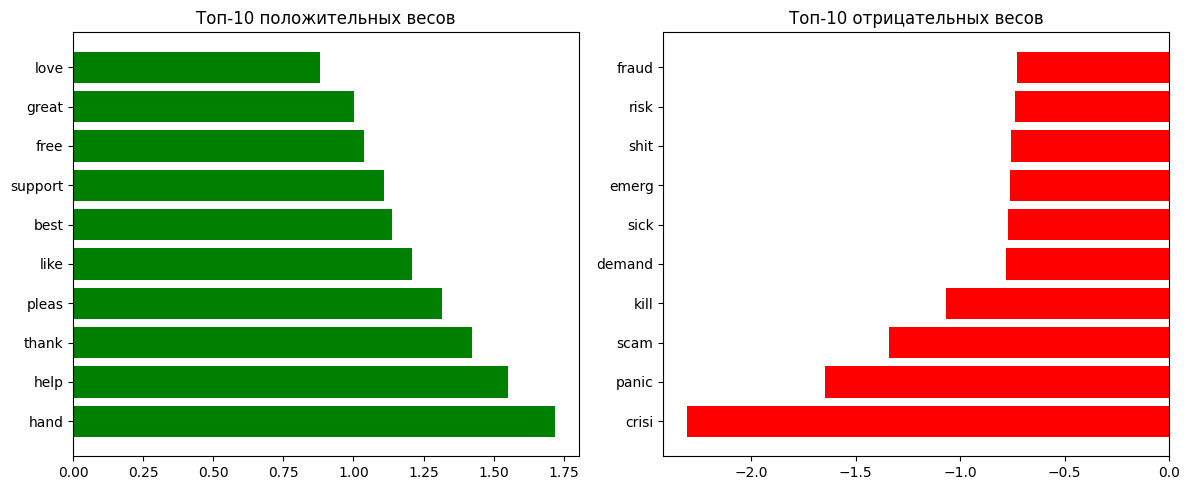

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_cv)
X_test_scaled = scaler.transform(X_test_cv)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

print(f"Train accuracy: {accuracy_score(y_train, lr.predict(X_train_scaled))}")
print(f"Test accuracy: {accuracy_score(y_test, lr.predict(X_test_scaled))}")

features = np.array(cv.get_feature_names_out())
coef = lr.coef_[0]

pos_idx = np.argsort(coef)[-10:][::-1]
neg_idx = np.argsort(coef)[:10]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.barh(features[pos_idx], coef[pos_idx], color='green')
plt.title('Топ-10 положительных весов')
plt.subplot(1, 2, 2)
plt.barh(features[neg_idx], coef[neg_idx], color='red')
plt.title('Топ-10 отрицательных весов')
plt.tight_layout()
plt.show()

**Ответ:** модель хорошо отобрала положительные и отрицательные токены. В положительных мы видим, чувства, вежливость , благодарность. В отрицательных негативные эмоции, риски и опасность.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:

from scipy.sparse import hstack

X = df['OriginalTweet']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cv = CountVectorizer(tokenizer=custom_stem_tokenizer)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

train_df = df.loc[X_train.index]
test_df = df.loc[X_test.index]

user_train = pd.get_dummies(train_df['UserName'])
user_test = pd.get_dummies(test_df['UserName'])

user_train = user_train.loc[:, ~user_train.columns.duplicated()]
user_test = user_test.reindex(columns=user_train.columns, fill_value=0)

sc = StandardScaler(with_mean=False)
X_train_scaled = sc.fit_transform(X_train_cv)
X_test_scaled = sc.transform(X_test_cv)

X_train_combined = hstack([X_train_scaled, user_train.values])
X_test_combined = hstack([X_test_scaled, user_test.values])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_combined, y_train)

print(f"Train accuracy: {accuracy_score(y_train, lr.predict(X_train_combined))}")
print(f"Test accuracy: {accuracy_score(y_test, lr.predict(X_test_combined))}")

Train accuracy: 1.0000
Test accuracy: 0.7840


**Ответ:** UserName дает мало полезного, так как имен очень много и все они уникально, они не добавляют никакой тональности. Так же видно что наше модель переобучилась на train.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

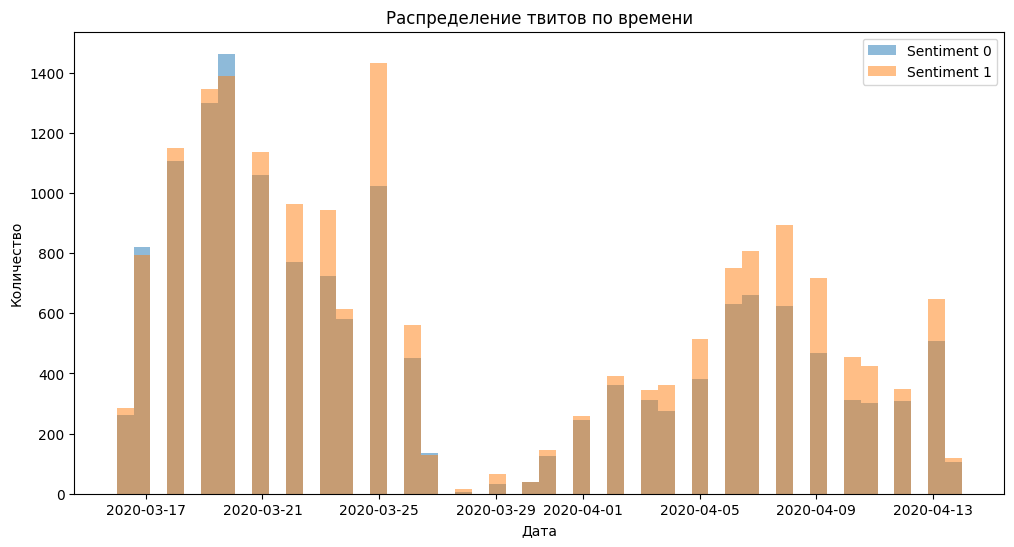

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df['TweetAt'] = pd.to_datetime(df['TweetAt'])

plt.figure(figsize=(12, 6))
for sentiment in [0, 1]:
    subset = df[df['Sentiment'] == sentiment]
    plt.hist(subset['TweetAt'], bins=50, alpha=0.5, label=f'Sentiment {sentiment}')
plt.legend()
plt.title('Распределение твитов по времени')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.show()



**Ответ:** видно что по какому-то временному промежутку нельзя выделить четко, что были только отрицательные или положительные твиты, поэтому этот признак не полезен.



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [ ]:
unique_locations = df['Location'].nunique()
print(f'Уникальных значений {unique_locations}')

Уникальных значений 10465


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

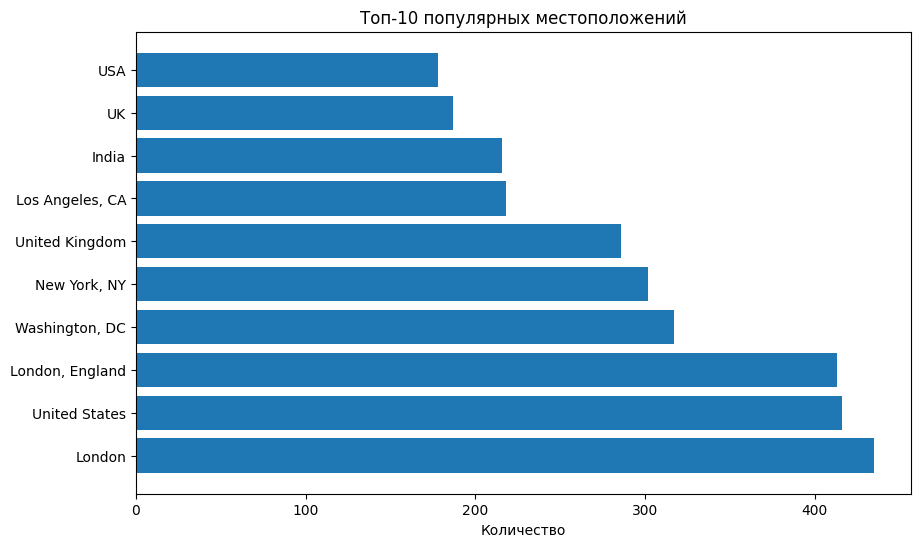

In [ ]:


location_counts = df[df['Location'] != 'Unknown']['Location'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(location_counts.index, location_counts.values)
plt.xlabel('Количество')
plt.title('Топ-10 популярных местоположений')
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

Уникальных WiderLocation: 6118


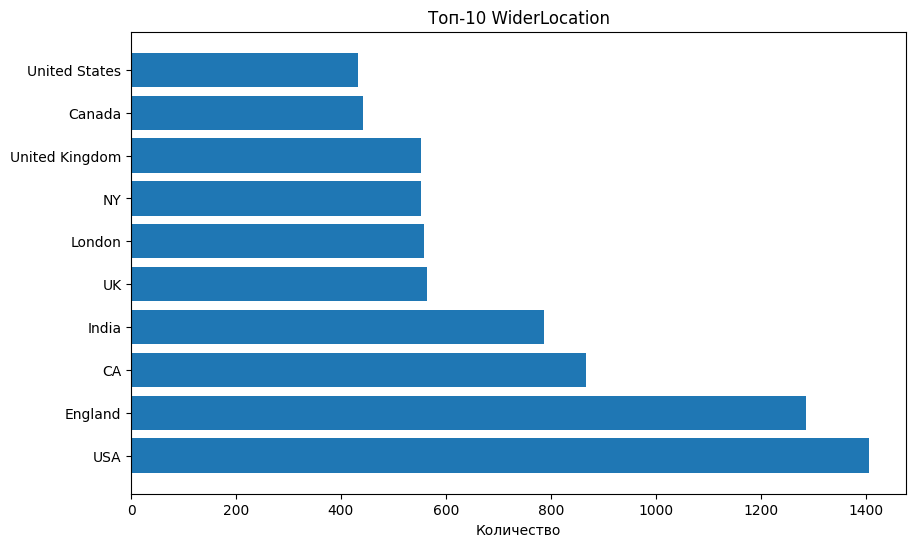

In [ ]:
def extract_wider_location(loc):
    if loc == 'Unknown':
        return 'Unknown'
    parts = loc.split(',')
    if len(parts) > 1:
        return parts[-1].strip()
    return loc.strip()

df['WiderLocation'] = df['Location'].apply(extract_wider_location)

unique_wider = df['WiderLocation'].nunique()
print(f'Уникальных WiderLocation: {unique_wider}')

wider_counts = df[df['WiderLocation'] != 'Unknown']['WiderLocation'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(wider_counts.index, wider_counts.values)
plt.xlabel('Количество')
plt.title('Топ-10 WiderLocation')
plt.show()

число уникальных значений уменьшилось, так как было обобщение + поменялись лидеры среди локаций.

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [ ]:
loc_count = df['WiderLocation'].value_counts()
new_loc = loc_count[loc_count > 1].index

print("Количество локаций : ", len(new_loc))

loc_dum = pd.get_dummies(df['WiderLocation'], prefix='loc')
loc_dum = loc_dum[[col for col in loc_dum.columns if col.replace('loc_', '') in new_loc]]



Количество локаций :  1308


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:

from sklearn.preprocessing import OneHotEncoder

X = df['OriginalTweet']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cv = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

train_df = df.loc[X_train.index]
test_df = df.loc[X_test.index]



e = OneHotEncoder(handle_unknown='ignore')
e.categories = [new_loc]

loc_train = e.fit_transform(train_df[['WiderLocation']])
loc_test = e.transform(test_df[['WiderLocation']])

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_cv)
X_test_scaled = scaler.transform(X_test_cv)

X_train_combined = hstack([X_train_scaled, loc_train])
X_test_combined = hstack([X_test_scaled, loc_test])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_combined, y_train)

print(f"Train accuracy: {accuracy_score(y_train, lr.predict(X_train_combined))}")
print(f"Test accuracy: {accuracy_score(y_test, lr.predict(X_test_combined))}")

Train accuracy: 0.9999626238086339
Test accuracy: 0.7841231873224698


**Ответ:** локация тоже не дала каких-то значительных улучшений предсказаний тональности твита, на тесте качество осталось таким же, а на трейне есть переобучение.